# Observables and change of basis: Sampler versus Estimator

A quantum computer only returns bitstrings from Z-basis measurements. Yet we often want an *expectation value* $\langle O\rangle$ of an observable $O$. There are two ways to get one.

**Sampler (do it yourself).** Run circuits that end in measurements, get counts, and compute the expectation value from the counts. For $O = Z$ with $n_0$ zeros and $n_1$ ones, $\langle Z\rangle = (n_0 - n_1)/N$. To measure $X$ you must first change basis: since $X = HZH$, apply H before measuring and treat the result as Z. An observable made of several non-commuting terms (here $Z + X$) needs one circuit per term, and you add up the results.

**Estimator (let Qiskit do it).** Give it a circuit *without* measurements and the observable. It picks the basis changes, runs the circuits, combines the terms, and returns the expectation value together with its standard error.

## The experiment

The state $R_y(\theta)|0\rangle = \cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle$ has $\langle Z\rangle = \cos\theta$ and $\langle X\rangle = \sin\theta$. The observable is $O = Z + X$, so $\langle O\rangle = \cos\theta + \sin\theta$. We sweep $\theta$ in a single PUB using a circuit *parameter*.

## The steps

Every example in this folder follows the same recipe:

1. **Circuit**: build the abstract circuit.
2. **Transpile**: rewrite it into the gates and qubits the backend supports (an "ISA circuit").
3. **Observable**: what to measure (Estimator only).
4. **PUB**: bundle what to run (a Primitive Unified Bloc, a tuple that starts with the circuit).
5. **Execute**: hand the PUBs to a primitive and wait for the job.
6. **Read**: turn the raw result into numbers and compare with theory.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue.

In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# _runtime.py (in ../scripts) only decides *where* to run: Aer and/or IBM hardware.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from _runtime import get_targets

np.set_printoptions(precision=3, suppress=True)

SETTINGS = SimpleNamespace(
    shots=4096,                  # shots per circuit (Sampler jobs)
    precision=0.02,              # target standard error (Estimator jobs)
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)
targets = get_targets(SETTINGS)
print("Running on:", [t.label for t in targets])

Running on: ['aer']


## Step 1: Circuit

`theta` is a placeholder, not yet a number. The circuit has no measurement.

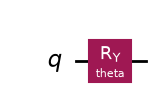

In [2]:
from qiskit.circuit import Parameter

THETA = Parameter("theta")
# Shape (num_points, num_parameters): one row per theta value.
THETA_VALUES = np.linspace(0, np.pi, 7).reshape(-1, 1)

qubits = QuantumRegister(1, name="q")
state = QuantumCircuit(qubits, name="ry_state")
state.ry(THETA, qubits[0])
state.draw("mpl")

## Step 3: Observable

$Z + X$ as Pauli strings. The two terms do not commute, so no single measurement basis gives both. That is why a Sampler needs two circuits.

In [3]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp(["Z", "X"], coeffs=[1.0, 1.0])
print(observable.to_list())

exact = np.cos(THETA_VALUES[:, 0]) + np.sin(THETA_VALUES[:, 0])

[('Z', (1+0j)), ('X', (1+0j))]


## Part A: Sampler, by hand

We need one circuit that measures Z directly and one that applies H first (the change of basis) so the Z measurement acts as an X measurement.

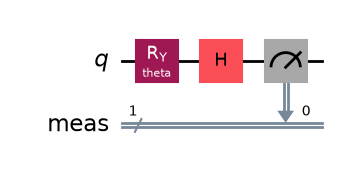

In [4]:
def with_measurement(state, basis):
    circuit = state.copy(name=f"measure_{basis}")
    bits = ClassicalRegister(1, name="meas")
    circuit.add_register(bits)
    if basis == "X":
        circuit.h(0)
    circuit.measure(0, bits)
    return circuit


def expectation_from_counts(counts):
    n0, n1 = counts.get("0", 0), counts.get("1", 0)
    return (n0 - n1) / (n0 + n1)


with_measurement(state, "X").draw("mpl")

Steps 2, 4, 5: transpile once per backend (the parameter survives), then make one PUB per circuit as `(circuit, parameter values)`. All seven theta values travel in one PUB.

In [5]:
sampler_results = {}
for target in targets:
    pass_manager = generate_preset_pass_manager(backend=target.backend, optimization_level=1)
    isa_z = pass_manager.run(with_measurement(state, "Z"))
    isa_x = pass_manager.run(with_measurement(state, "X"))
    sampler_pubs = [(isa_z, THETA_VALUES), (isa_x, THETA_VALUES)]
    sampler_results[target.label] = target.wait(
        target.sampler.run(sampler_pubs, shots=SETTINGS.shots)
    )

Step 6: `data.meas` is a bit array with one entry per theta value, and `get_counts(i)` picks the i-th.

In [6]:
by_hand = {}
for label, result in sampler_results.items():
    if result is None:
        continue
    z_bits, x_bits = (r.data.meas for r in result)
    by_hand[label] = np.array([
        expectation_from_counts(z_bits.get_counts(i)) + expectation_from_counts(x_bits.get_counts(i))
        for i in range(len(THETA_VALUES))
    ])

## Part B: Estimator

Steps 2 to 5: transpile the circuit with *no* measurements. The transpiler may place the qubit on a different physical qubit, so rewrite the observable to match. The PUB is `(circuit, observable, parameter values)`.

In [7]:
estimates = {}
for target in targets:
    pass_manager = generate_preset_pass_manager(backend=target.backend, optimization_level=1)
    isa_state = pass_manager.run(state)
    isa_observable = observable.apply_layout(isa_state.layout)
    estimator_pubs = [(isa_state, isa_observable, THETA_VALUES)]
    result = target.wait(target.estimator.run(estimator_pubs, precision=SETTINGS.precision))
    if result is not None:
        # One number and one standard error per theta value.
        estimates[target.label] = (np.asarray(result[0].data.evs), np.asarray(result[0].data.stds))

## Compare


aer:  theta/pi   exact   Sampler (by hand)   Estimator (ev +/- std)
            0.000  +1.000              +0.987   +0.986 +/- 0.020
            0.167  +1.366              +1.354   +1.393 +/- 0.020
            0.333  +1.366              +1.361   +1.341 +/- 0.020
            0.500  +1.000              +1.016   +1.017 +/- 0.020
            0.667  +0.366              +0.366   +0.354 +/- 0.020
            0.833  -0.366              -0.340   -0.327 +/- 0.020
            1.000  -1.000              -0.994   -0.994 +/- 0.020


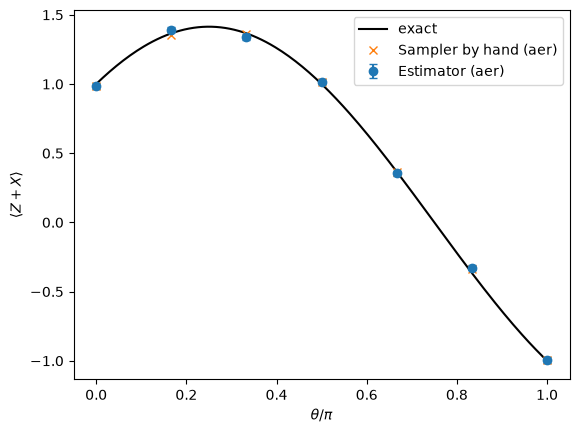

In [8]:
import matplotlib.pyplot as plt

for target in targets:
    label = target.label
    print(f"\n{label}:  theta/pi   exact   Sampler (by hand)   Estimator (ev +/- std)")
    for i, theta in enumerate(THETA_VALUES[:, 0]):
        s = f"{by_hand[label][i]:+.3f}" if label in by_hand else "n/a"
        e = (f"{estimates[label][0][i]:+.3f} +/- {estimates[label][1][i]:.3f}"
             if label in estimates else "n/a")
        print(f"  {theta / np.pi:15.3f}  {exact[i]:+.3f}   {s:>17}   {e}")

fig, ax = plt.subplots()
x = THETA_VALUES[:, 0] / np.pi
fine = np.linspace(0, 1, 200)
ax.plot(fine, np.cos(np.pi * fine) + np.sin(np.pi * fine), "k-", label="exact")
for label, (evs, stds) in estimates.items():
    ax.errorbar(x, evs, yerr=stds, fmt="o", capsize=3, label=f"Estimator ({label})")
for label, values in by_hand.items():
    ax.plot(x, values, "x", label=f"Sampler by hand ({label})")
ax.set_xlabel(r"$\theta / \pi$")
ax.set_ylabel(r"$\langle Z + X \rangle$")
ax.legend()
plt.show()

## Takeaway

Both methods recover $\cos\theta + \sin\theta$. The Sampler needed us to add an H and combine counts by hand. The Estimator did that bookkeeping and also reported the uncertainty.